In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[0], 'GPU')

import hmc_2hl as hmc

In [15]:
d = 100
alpha = 1.75
gamma_1 = 0.5
gamma_2 = 0.5

Delta = 0.2
vlaw = 'gaussd'
k1 = int(gamma_1 * d)
k2 = int(gamma_2 * d)

sig_1 = lambda x: tf.nn.tanh(2*x) / 0.797032
sig_2 = lambda x: tf.nn.tanh(2*x) / 0.797032

params = {
    'step_size': 0.01,
    'num_leapfrog_steps': 10,
    'num_adaptation_steps': 30000,
}

ntest = 10000
Xtest = tf.random.normal((d, ntest), dtype=tf.float32)


In [16]:
W10, W20, v, X, Y = hmc.data_generate(d, alpha, gamma_1, gamma_2, sig_1, sig_2, Delta, vlaw)
W1s_info, W2s_info = hmc.hmc(params, W10, W20, v, X, Y, Delta, sig_1, sig_2, info=True)
test_info = hmc.test_error(W1s_info, W2s_info, W10, W20, v, sig_1, sig_2, Xtest)

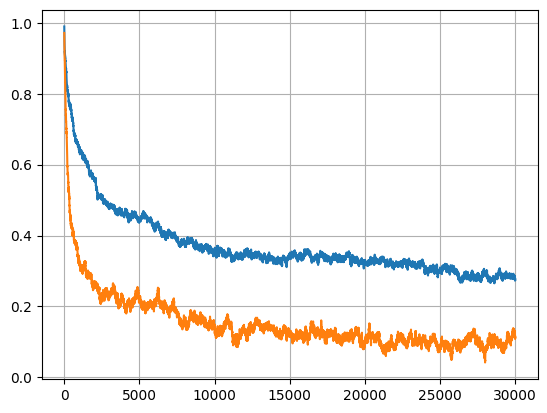

In [17]:
qw1s = [tf.reduce_mean(W1*W10) for W1 in W1s_info]
qw2s = [tf.reduce_mean(W2*W20) for W2 in W2s_info]
plt.plot(qw1s, label='W_1 overlap')
plt.plot(qw2s, label='W_2 overlap')
plt.grid()
# plt.savefig('al_1.75_qw.pdf')
plt.show()

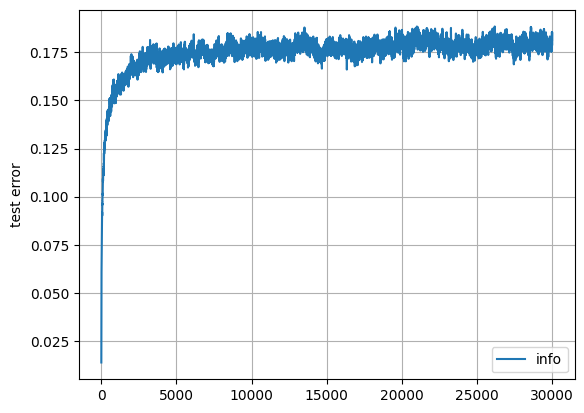

In [18]:
plt.plot(test_info, label='info')
plt.ylabel('test error')
plt.legend()
# plt.savefig('al_1.75_err.pdf')
plt.grid()
plt.show()